<a href="https://colab.research.google.com/github/Helen13JS/SIS420_Inteligencia_Artificial/blob/main/Laboratorios/Laboratorio2/Lab2_regresion_elecciones_portugal_2019_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regresión Lineal Multivariable, Ecuación Normal y Regresión Polinómica
Janko Sanga Helen Ing. Sistemas
## Dataset: Real-Time Election Results — Portugal 2019
### Fuente:https://archive.ics.uci.edu/dataset/513/real+time+election+results+portugal+2019

Este cuadernillo implementa **desde cero con NumPy** tres modelos de regresión para predecir
la cantidad de votos (`Votes`) que obtiene un partido político en un territorio electoral portugués.

| Requisito | Valor |
|-----------|-------|
| Ejemplos m | 20 509 ≥ 20 000  |
| Características n | 56 ≥ 20  |
| Predicciones de prueba | 100  |

**Modelos implementados:**
1. Regresión Lineal Multivariable — Descenso por Gradiente
2. Ecuación Normal
3. Regresión Polinómica de Grado 2 — Descenso por Gradiente

## 1. Importación de Librerías

In [30]:
import numpy as np
import pandas as pd
from matplotlib import pyplot
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')
print("Librerías cargadas correctamente.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Librerías cargadas correctamente.


## 2. Carga y Exploración del Dataset

El dataset proviene del **UCI Machine Learning Repository** y contiene los resultados
electorales en tiempo real de las elecciones legislativas de Portugal del 6 de octubre de 2019.
Cada fila es un *snapshot* de un partido en un territorio en un instante de tiempo.

**Columnas principales:**
- `TimeElapsed` — minutos desde el inicio del conteo (0 a 265)
- `territoryName` — nombre del distrito (20 distritos)
- `Party` — partido político (21 partidos)
- `Votes` — votos obtenidos → **variable objetivo y**
- `availableMandates`, `subscribedVoters`, `totalVoters`, `votersPercentage`, entre otras

In [31]:
RUTA = '/content/drive/MyDrive/Colab_Projects_AI/datasets/ElectionData.csv'
df_raw = pd.read_csv(RUTA)
print(f"Dimensiones originales: {df_raw.shape[0]} filas x {df_raw.shape[1]} columnas")
df_raw.head(5)

Dimensiones originales: 21643 filas x 28 columnas


,TimeElapsed,time,territoryName,totalMandates,availableMandates,numParishes,numParishesApproved,blankVotes,blankVotesPercentage,nullVotes,...,pre.votersPercentage,pre.subscribedVoters,pre.totalVoters,Party,Mandates,Percentage,validVotesPercentage,Votes,Hondt,FinalMandates
0,0,2019-10-06 20:10:02,Território Nacional,0,226,3092,1081,9652,2.5,8874,...,52.66,813743,428546,PS,0,38.29,40.22,147993,94,106
1,0,2019-10-06 20:10:02,Território Nacional,0,226,3092,1081,9652,2.5,8874,...,52.66,813743,428546,PPD/PSD,0,33.28,34.95,128624,81,77
2,0,2019-10-06 20:10:02,Território Nacional,0,226,3092,1081,9652,2.5,8874,...,52.66,813743,428546,B.E.,0,6.81,7.15,26307,16,19
3,0,2019-10-06 20:10:02,Território Nacional,0,226,3092,1081,9652,2.5,8874,...,52.66,813743,428546,CDS-PP,0,4.90,5.14,18923,12,5
4,0,2019-10-06 20:10:02,Território Nacional,0,226,3092,1081,9652,2.5,8874,...,52.66,813743,428546,PCP-PEV,0,4.59,4.83,17757,11,12


In [32]:
print(df_raw.dtypes)

TimeElapsed                   int64
time                         object
territoryName                object
totalMandates                 int64
availableMandates             int64
numParishes                   int64
numParishesApproved           int64
blankVotes                    int64
blankVotesPercentage        float64
nullVotes                     int64
nullVotesPercentage         float64
votersPercentage            float64
subscribedVoters              int64
totalVoters                   int64
pre.blankVotes                int64
pre.blankVotesPercentage    float64
pre.nullVotes                 int64
pre.nullVotesPercentage     float64
pre.votersPercentage        float64
pre.subscribedVoters          int64
pre.totalVoters               int64
Party                        object
Mandates                      int64
Percentage                  float64
validVotesPercentage        float64
Votes                         int64
Hondt                         int64
FinalMandates               

In [33]:
df_raw.describe()

,TimeElapsed,totalMandates,availableMandates,numParishes,numParishesApproved,blankVotes,blankVotesPercentage,nullVotes,nullVotesPercentage,votersPercentage,...,pre.nullVotesPercentage,pre.votersPercentage,pre.subscribedVoters,pre.totalVoters,Mandates,Percentage,validVotesPercentage,Votes,Hondt,FinalMandates
count,21643.000000,21643.000000,21643.000000,21643.000000,21643.000000,21643.000000,21643.000000,21643.000000,21643.000000,21643.000000,...,21643.000000,21643.000000,2.164300e+04,2.164300e+04,21643.000000,21643.000000,21643.000000,2.164300e+04,21643.000000,21643.000000
mean,133.146052,11.544795,11.499284,309.956013,261.090237,8875.066673,2.621629,6148.068752,1.961471,51.983722,...,1.777442,54.549372,6.378503e+05,3.594932e+05,0.565495,4.968484,5.207232,1.585209e+04,1.126138,1.126138
std,77.651193,31.314567,31.738783,659.055911,583.377428,21484.874088,0.795289,14735.469269,0.375250,4.854380,...,0.388798,4.964948,1.544418e+06,8.763729e+05,4.421804,10.379967,10.881108,9.310605e+04,6.293552,6.872644
min,0.000000,0.000000,0.000000,54.000000,3.000000,19.000000,0.530000,39.000000,1.340000,35.980000,...,1.140000,40.870000,6.383000e+03,3.215000e+03,0.000000,0.020000,0.020000,1.000000e+00,0.000000,0.000000
25%,65.000000,1.000000,0.000000,75.000000,67.000000,1188.000000,2.230000,1094.000000,1.720000,50.290000,...,1.520000,51.210000,1.289260e+05,6.964400e+04,0.000000,0.220000,0.230000,2.360000e+02,0.000000,0.000000
50%,135.000000,4.000000,3.000000,147.000000,120.000000,2998.000000,2.640000,2232.000000,1.870000,53.130000,...,1.690000,56.260000,2.284970e+05,1.102730e+05,0.000000,0.620000,0.650000,7.900000e+02,0.000000,0.000000
75%,200.000000,9.000000,9.000000,242.000000,208.000000,6889.000000,2.980000,4121.000000,2.230000,54.550000,...,1.970000,58.220000,3.933140e+05,2.276200e+05,0.000000,3.010000,3.160000,4.510000e+03,0.000000,0.000000
max,265.000000,226.000000,226.000000,3092.000000,3092.000000,129599.000000,5.460000,88539.000000,3.350000,59.870000,...,3.120000,62.580000,9.439701e+06,5.380451e+06,106.000000,49.110000,51.420000,1.866407e+06,94.000000,106.000000


## 3. Preprocesamiento del Dataset

### 3.1 Filtrado de filas y columnas
Se elimina la fila del agregado nacional `'Território Nacional'` (es la suma de los 20 distritos
y duplicaría la información).
Se eliminan columnas que no aportan información al modelo:
- `totalMandates` → constante igual a 0 en todo el dataset
- `pre.*` → datos preliminares, ya contamos con los valores finales
- `time` → redundante con `TimeElapsed`
- `Mandates` → se usa `FinalMandates` que es el valor definitivo

### 3.2 Nuevas características derivadas
A partir de las columnas existentes se crean dos características adicionales:
- `parishApprovalRate` = numParishesApproved / numParishes → fracción de parroquias ya contabilizadas
- `nullBlankRate` = (nullVotes + blankVotes) / totalVoters → ratio de votos no válidos sobre el total

Estas variables resumen información que originalmente estaba dispersa en varias columnas.

### 3.3 Codificación de variables categóricas (One-Hot Encoding)
Las variables `Party` (21 categorías) y `territoryName` (20 categorías) no son numéricas,
por lo que no pueden ingresarse directamente al modelo. Se convierten en columnas binarias
(0 = no pertenece, 1 = pertenece) eliminando una categoría de referencia para evitar
multicolinealidad. Esto agrega 20 + 19 = 39 columnas al dataset.

**Resultado final: m = 20 509 ejemplos, n = 56 características**

In [34]:
df = df_raw.copy()
df = df[df['territoryName'] != 'Território Nacional'].copy()
print(f"Filas tras eliminar agregado nacional: {len(df)}")

cols_drop = [
    'totalMandates',
    'pre.blankVotes','pre.blankVotesPercentage',
    'pre.nullVotes','pre.nullVotesPercentage',
    'pre.votersPercentage','pre.subscribedVoters','pre.totalVoters',
    'time','Mandates',
]
df.drop(columns=cols_drop, inplace=True)
print(f"Columnas tras limpieza: {df.shape[1]}")
df.head(3)

Filas tras eliminar agregado nacional: 20509
Columnas tras limpieza: 18


,TimeElapsed,territoryName,availableMandates,numParishes,numParishesApproved,blankVotes,blankVotesPercentage,nullVotes,nullVotesPercentage,votersPercentage,subscribedVoters,totalVoters,Party,Percentage,validVotesPercentage,Votes,Hondt,FinalMandates
21,0,Aveiro,16,147,12,186,2.92,101,1.59,53.3,11953,6371,PPD/PSD,37.75,39.53,2405,7,6
22,0,Aveiro,16,147,12,186,2.92,101,1.59,53.3,11953,6371,PS,34.33,35.95,2187,7,7
23,0,Aveiro,16,147,12,186,2.92,101,1.59,53.3,11953,6371,B.E.,7.47,7.82,476,1,2


In [35]:
df['parishApprovalRate'] = df['numParishesApproved'] / df['numParishes'].replace(0,1)
df['nullBlankRate']      = (df['nullVotes'] + df['blankVotes']) / df['totalVoters'].replace(0,1)
print("Nuevas características creadas: parishApprovalRate, nullBlankRate")
df[['parishApprovalRate','nullBlankRate']].describe()

Nuevas características creadas: parishApprovalRate, nullBlankRate


,parishApprovalRate,nullBlankRate
count,20509.000000,20509.000000
mean,0.828153,0.045860
std,0.279019,0.009348
min,0.044776,0.022034
25%,0.775510,0.039211
50%,0.990909,0.047706
75%,1.000000,0.049487
max,1.000000,0.068770


In [36]:
df_enc = pd.get_dummies(df, columns=['Party','territoryName'], drop_first=True)
bool_cols = df_enc.select_dtypes(include='bool').columns
df_enc[bool_cols] = df_enc[bool_cols].astype(int)
print(f"Dimensiones tras one-hot encoding: {df_enc.shape}")
print(f"  m = {df_enc.shape[0]}  ->  cumple m >= 20 000 ✓")
print(f"  n = {df_enc.shape[1]-1}  ->  cumple n >= 20 ✓")

Dimensiones tras one-hot encoding: (20509, 57)
  m = 20509  ->  cumple m >= 20 000 ✓
  n = 56  ->  cumple n >= 20 ✓


In [37]:
TARGET = 'Votes'
feature_cols = [c for c in df_enc.columns if c != TARGET]
X_all = df_enc[feature_cols].values.astype(float)
y_all = df_enc[TARGET].values.astype(float)
m_total, n_total = X_all.shape
print(f"X shape: {X_all.shape}  |  y shape: {y_all.shape}")
print(f"Rango de y (Votes): {y_all.min():.0f}  –  {y_all.max():.0f}")

X shape: (20509, 56)  |  y shape: (20509,)
Rango de y (Votes): 1  –  404677


## 4. Exploración Visual del Dataset

Antes de entrenar cualquier modelo es importante entender los datos visualmente.
Se presentan **tres gráficos esenciales**:

1. **Distribución de Votes** — muestra que la mayoría de partidos obtienen pocos votos
   en distritos pequeños, con muy pocos casos de muchos votos. Esta asimetría es típica
   de datos electorales.

2. **Electores registrados vs Votes** — a mayor número de electores en un distrito,
   mayor cantidad de votos. La relación no es perfectamente lineal, lo que ya anticipa
   que un modelo polinómico funcionará mejor que uno lineal.

3. **Evolución temporal por partido** — muestra cómo los votos se van acumulando a medida
   que avanzan los minutos del conteo. Los partidos grandes (PS, PPD/PSD) acumulan votos
   más rápido porque ganan en más distritos.

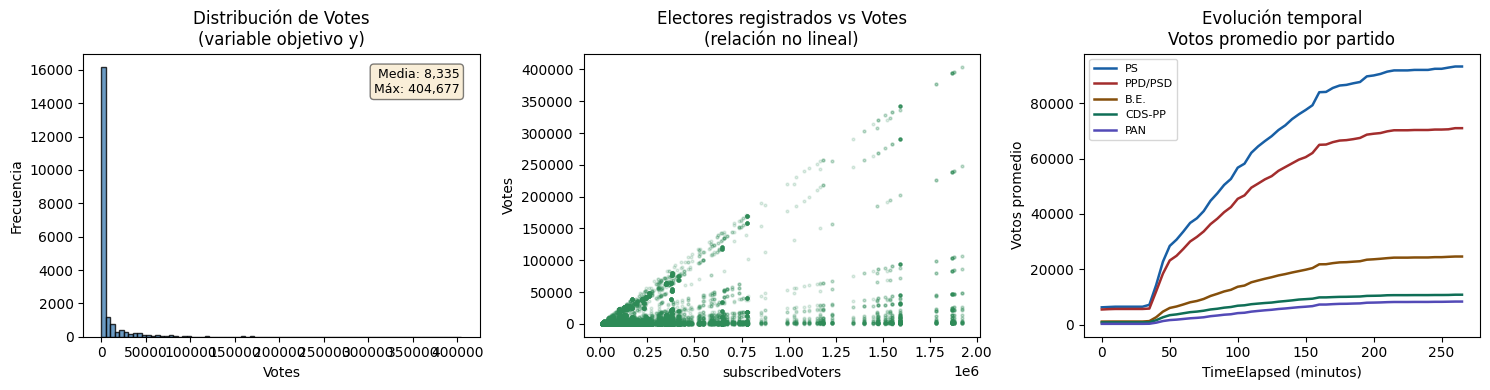

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Distribución de Votes (variable objetivo)
axes[0].hist(y_all, bins=80, color='steelblue', edgecolor='k', alpha=0.8)
axes[0].set_title('Distribución de Votes\n(variable objetivo y)')
axes[0].set_xlabel('Votes')
axes[0].set_ylabel('Frecuencia')
axes[0].text(0.95, 0.95,
    f'Media: {y_all.mean():,.0f}\nMáx: {y_all.max():,.0f}',
    transform=axes[0].transAxes, ha='right', va='top', fontsize=9,
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 2. Electores registrados vs Votes
axes[1].scatter(df['subscribedVoters'], df['Votes'], alpha=0.15, s=4, color='seagreen')
axes[1].set_title('Electores registrados vs Votes\n(relación no lineal)')
axes[1].set_xlabel('subscribedVoters')
axes[1].set_ylabel('Votes')

# 3. Evolución temporal de los 5 partidos principales
top_p = ['PS','PPD/PSD','B.E.','CDS-PP','PAN']
colors_p = ['#185FA5','#A32D2D','#854F0B','#0F6E56','#534AB7']
for p, col in zip(top_p, colors_p):
    sub = df_raw[(df_raw['Party']==p) & (df_raw['territoryName']!='Território Nacional')]
    avg = sub.groupby('TimeElapsed')['Votes'].mean()
    axes[2].plot(avg.index.astype(int), avg.values, label=p, color=col, linewidth=1.8)
axes[2].set_title('Evolución temporal\nVotos promedio por partido')
axes[2].set_xlabel('TimeElapsed (minutos)')
axes[2].set_ylabel('Votos promedio')
axes[2].legend(fontsize=8)

pyplot.tight_layout()
pyplot.savefig('exploracion_dataset.png', dpi=100, bbox_inches='tight')
pyplot.show()

## 5. Normalización de Características y División Train/Test

### ¿Por qué normalizar?
Las características tienen magnitudes muy diferentes: `subscribedVoters` puede valer
700 000 mientras que `parishApprovalRate` vale entre 0 y 1. Si se aplica el descenso
por gradiente directamente, el gradiente se desvía hacia la característica de mayor
magnitud y converge muy lentamente o diverge.

La normalización z-score lleva todas las características a la misma escala (media=0,
desviación estándar=1):

$$x_j^{\text{norm}} = \frac{x_j - \mu_j}{\sigma_j}$$

**Importante:** la ecuación normal no requiere normalización en teoría, pero se aplica
igualmente para mantener la misma base de comparación entre los tres modelos.

### División Train / Test (80 % / 20 %)
- **Entrenamiento** (~16 407 ejemplos): se usan para calcular θ
- **Prueba** (~4 102 ejemplos): se usan para evaluar qué tan bien generaliza el modelo
  a datos que nunca vio durante el entrenamiento

In [39]:
def featureNormalize(X):
    """
    Normaliza X por z-score columna a columna.
    Devuelve X_norm, mu, sigma.
    Columnas constantes (sigma=0) se dejan sin cambio.
    """
    mu    = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

X_norm, mu, sigma = featureNormalize(X_all)
print(f"Media  (primeras 5 cols): {mu[:5].round(2)}")
print(f"Sigma  (primeras 5 cols): {sigma[:5].round(2)}")
print(f"X_norm — min: {X_norm.min():.3f}  max: {X_norm.max():.3f}  media~={X_norm.mean():.8f}")

Media  (primeras 5 cols): [ 133.18    5.91  156.13  131.26 4536.77]
Sigma  (primeras 5 cols): [  77.63    9.96   82.06   85.29 5055.39]
X_norm — min: -3.207  max: 10.196  media~=-0.00000000


In [40]:
np.random.seed(42)
indices   = np.random.permutation(m_total)
split     = int(0.80 * m_total)
idx_train = indices[:split]
idx_test  = indices[split:]

X_train, y_train = X_norm[idx_train], y_all[idx_train]
X_test,  y_test  = X_norm[idx_test],  y_all[idx_test]
m_train = X_train.shape[0]
m_test  = X_test.shape[0]

print(f"Entrenamiento: {m_train} ejemplos")
print(f"Prueba:        {m_test} ejemplos")

# Columna de unos para el término independiente theta0
X_train_b = np.concatenate([np.ones((m_train,1)), X_train], axis=1)
X_test_b  = np.concatenate([np.ones((m_test, 1)), X_test],  axis=1)
print(f"\nX_train_b shape: {X_train_b.shape}  (m x n+1)")

Entrenamiento: 16407 ejemplos
Prueba:        4102 ejemplos

X_train_b shape: (16407, 57)  (m x n+1)


## 6. Modelo 1 — Regresión Lineal Multivariable (Descenso por Gradiente)

### Función de hipótesis
$$h_\theta(x) = \theta_0 + \theta_1 x_1 + \cdots + \theta_n x_n = \theta^T x$$

### Función de costo
$$J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right)^2$$

### Actualización de parámetros (forma vectorial)
$$\theta := \theta - \frac{\alpha}{m} X^T (X\theta - \vec{y})$$

El algoritmo ajusta todos los $\theta_j$ simultáneamente en cada iteración.
$\alpha$ es la **tasa de aprendizaje**: controla qué tan grande es cada paso hacia el mínimo.
Un $\alpha$ demasiado grande hace que el costo suba en lugar de bajar (divergencia);
uno demasiado pequeño hace que converja muy lentamente.

In [41]:
def computeCostMulti(X, y, theta):
    """
    Calcula J(theta) — función de costo para regresión lineal.
    X: (m, n+1)  y: (m,)  theta: (n+1,)
    """
    m    = y.shape[0]
    diff = np.dot(X, theta) - y
    J    = (1.0 / (2.0 * m)) * np.dot(diff, diff)
    return J

def gradientDescentMulti(X, y, theta, alpha, num_iters):
    """
    Descenso por gradiente para regresión lineal multivariable.
    Devuelve theta optimizado y el historial de costos J_history.
    """
    m     = y.shape[0]
    theta = theta.copy()
    J_history = []
    for _ in range(num_iters):
        error = np.dot(X, theta) - y
        theta = theta - (alpha / m) * np.dot(X.T, error)
        J_history.append(computeCostMulti(X, y, theta))
    return theta, J_history

In [42]:
alpha     = 0.01
num_iters = 1500
theta_init = np.zeros(X_train_b.shape[1])

print(f"Costo inicial (theta = 0): J = {computeCostMulti(X_train_b, y_train, theta_init):,.2f}")

theta_gd, J_history_gd = gradientDescentMulti(
    X_train_b, y_train, theta_init, alpha, num_iters)

print(f"Costo final  (iter {num_iters}): J = {J_history_gd[-1]:,.2f}")
print(f"\nPrimeros 5 valores de theta: {theta_gd[:5].round(4)}")

Costo inicial (theta = 0): J = 419,298,057.17
Costo final  (iter 1500): J = 99,675,850.42

Primeros 5 valores de theta: [ 8379.2763  -576.9796 -2809.8964  -253.4104  -171.8664]


### Gráfico de convergencia del costo — Modelo 1

El gráfico muestra cómo disminuye el error $J(\theta)$ a lo largo de las iteraciones.

- **Lo que se espera ver:** la curva cae rápidamente al inicio (cuando los $\theta$ están
  lejos del óptimo) y luego se aplana gradualmente conforme se acerca al mínimo.
- **Cómo leerlo:** si la curva nunca se aplana, necesitamos más iteraciones. Si sube,
  el $\alpha$ es demasiado grande. En nuestro caso converge correctamente.
- **Por qué no se ve una parábola aquí:** este gráfico muestra el *proceso de aprendizaje*
  (iteraciones vs error), no la forma del espacio de costo. La parábola aparece en el
  gráfico de la Ecuación Normal.

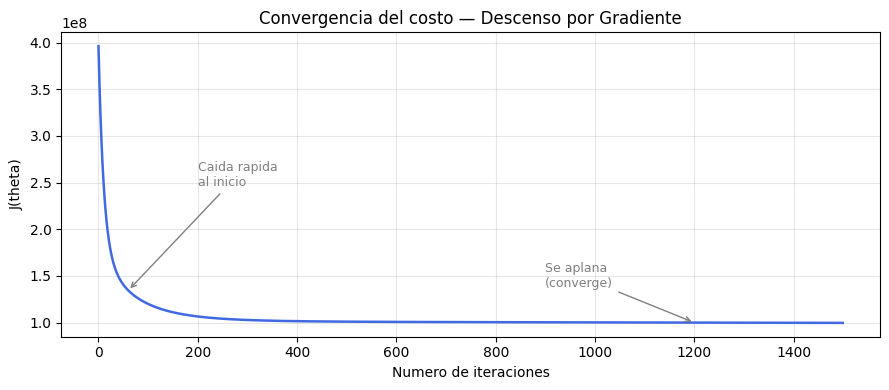

In [43]:
fig, ax = pyplot.subplots(figsize=(9, 4))

ax.plot(range(num_iters), J_history_gd, color='royalblue', linewidth=1.8)
ax.set_title('Convergencia del costo — Descenso por Gradiente')
ax.set_xlabel('Numero de iteraciones')
ax.set_ylabel('J(theta)')
ax.grid(True, alpha=0.3)
ax.annotate('Caida rapida\nal inicio',
    xy=(60, J_history_gd[60]),
    xytext=(200, J_history_gd[5] * 0.80),
    arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9, color='gray')
ax.annotate('Se aplana\n(converge)',
    xy=(1200, J_history_gd[1200]),
    xytext=(900, J_history_gd[100] * 1.15),
    arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9, color='gray')

pyplot.tight_layout()
pyplot.savefig('costo_gradiente.png', dpi=100, bbox_inches='tight')
pyplot.show()

In [44]:
def computeMetrics(y_real, y_pred, nombre='Modelo'):
    """Calcula MSE, RMSE y R² con NumPy puro."""
    m_     = len(y_real)
    mse_   = (1.0 / m_) * np.sum((y_pred - y_real)**2)
    rmse_  = np.sqrt(mse_)
    ss_res = np.sum((y_real - y_pred)**2)
    ss_tot = np.sum((y_real - np.mean(y_real))**2)
    r2_    = 1.0 - ss_res / ss_tot
    print(f"=== {nombre} ===")
    print(f"  MSE  : {mse_:>15,.2f}")
    print(f"  RMSE : {rmse_:>15,.2f}")
    print(f"  R²   : {r2_:.6f}")
    return mse_, rmse_, r2_

y_pred_train_gd = np.dot(X_train_b, theta_gd)
y_pred_test_gd  = np.dot(X_test_b,  theta_gd)

print("--- Entrenamiento ---")
mse_tr_gd, rmse_tr_gd, r2_tr_gd = computeMetrics(y_train, y_pred_train_gd, 'Gradiente Train')
print("\n--- Prueba ---")
mse_te_gd, rmse_te_gd, r2_te_gd = computeMetrics(y_test,  y_pred_test_gd,  'Gradiente Test')

--- Entrenamiento ---
=== Gradiente Train ===
  MSE  :  199,351,700.85
  RMSE :       14,119.20
  R²   : 0.740812

--- Prueba ---
=== Gradiente Test ===
  MSE  :  245,230,732.10
  RMSE :       15,659.84
  R²   : 0.700152


## 7. Modelo 2 — Ecuación Normal

La Ecuación Normal calcula el vector $\theta$ óptimo directamente en **una sola operación**,
sin necesidad de iterar:

$$\theta = \left( X^T X \right)^{-1} X^T \vec{y}$$

**¿Por qué funciona?** La función de costo $J(\theta)$ es una parábola convexa en el
espacio de los parámetros. La ecuación normal encuentra analíticamente el punto donde
la derivada es cero, es decir, el fondo exacto de esa parábola.

**Ventaja:** solución exacta, no requiere elegir $\alpha$ ni número de iteraciones.  
**Desventaja:** invertir $X^T X$ tiene complejidad $O(n^3)$. Con $n=56$ es viable,
pero con $n > 10\,000$ se vuelve prohibitivo.

Se usa `np.linalg.pinv` (pseudo-inversa) en lugar de la inversa directa para mayor
estabilidad numérica ante matrices casi singulares.

In [45]:
def normalEqn(X, y):
    """
    Calcula theta = (X^T X)^{-1} X^T y.
    Usa pseudo-inversa para estabilidad numérica.
    """
    theta = np.dot(np.linalg.pinv(np.dot(X.T, X)), np.dot(X.T, y))
    return theta

theta_ne = normalEqn(X_train_b, y_train)
print("Primeros 5 valores de theta (Ecuación Normal):")
for i, t in enumerate(theta_ne[:5]):
    print(f"  theta[{i}] = {t:.6f}")

Primeros 5 valores de theta (Ecuación Normal):
  theta[0] = 8371.101653
  theta[1] = 23.322125
  theta[2] = 165.235715
  theta[3] = -618.418071
  theta[4] = 175.058950


### Gráfico de costo — Ecuación Normal

A diferencia del descenso por gradiente, la ecuación normal no genera un historial de
iteraciones. Para visualizar el costo se escala el vector $\theta$ óptimo con un factor
$k \in [0, 1.5]$ y se calcula $J(k \cdot \theta)$.

**Cómo leerlo:**
- En $k=0$ (theta = 0): el error es máximo, el modelo no predice nada.
- En $k=1$ (theta óptimo): el error es mínimo — la ecuación normal salta directo aquí.
- En $k>1$ (theta sobredimensionado): el error vuelve a subir.

La **curva en forma de parábola** es exactamente lo que el ingeniero muestra en clase:
el costo tiene un único mínimo global y la ecuación normal lo encuentra de una vez.

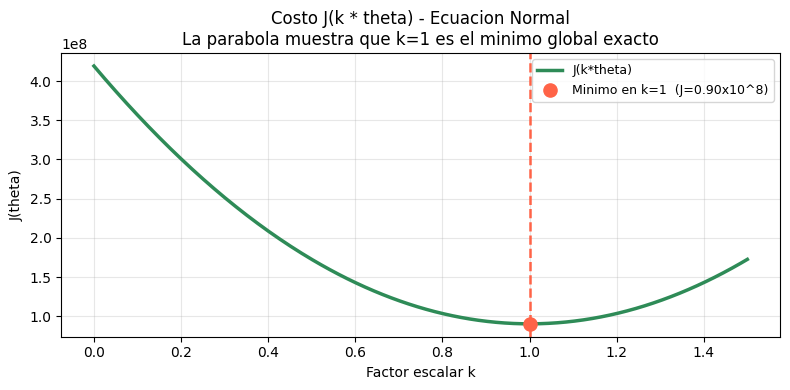

In [46]:
k_vals = np.linspace(0.0, 1.5, 300)
J_ne_k = [computeCostMulti(X_train_b, y_train, k * theta_ne) for k in k_vals]
min_J  = computeCostMulti(X_train_b, y_train, theta_ne)

pyplot.figure(figsize=(8, 4))
pyplot.plot(k_vals, J_ne_k, color='seagreen', linewidth=2.5, label='J(k*theta)')
pyplot.axvline(x=1.0, color='tomato', linestyle='--', linewidth=1.8)
pyplot.scatter([1.0], [min_J], color='tomato', s=90, zorder=5,
               label='Minimo en k=1  (J={:.2f}x10^8)'.format(min_J/1e8))
pyplot.title('Costo J(k * theta) - Ecuacion Normal\nLa parabola muestra que k=1 es el minimo global exacto')
pyplot.xlabel('Factor escalar k')
pyplot.ylabel('J(theta)')
pyplot.legend(fontsize=9)
pyplot.grid(True, alpha=0.3)
pyplot.tight_layout()
pyplot.savefig('costo_ec_normal.png', dpi=100, bbox_inches='tight')
pyplot.show()

In [47]:
y_pred_train_ne = np.dot(X_train_b, theta_ne)
y_pred_test_ne  = np.dot(X_test_b,  theta_ne)

print("--- Entrenamiento ---")
mse_tr_ne, rmse_tr_ne, r2_tr_ne = computeMetrics(y_train, y_pred_train_ne, 'Ec. Normal Train')
print("\n--- Prueba ---")
mse_te_ne, rmse_te_ne, r2_te_ne = computeMetrics(y_test,  y_pred_test_ne,  'Ec. Normal Test')

--- Entrenamiento ---
=== Ec. Normal Train ===
  MSE  :  180,492,057.36
  RMSE :       13,434.73
  R²   : 0.765333

--- Prueba ---
=== Ec. Normal Test ===
  MSE  :  222,908,810.51
  RMSE :       14,930.13
  R²   : 0.727445


## 8. Modelo 3 — Regresión Polinómica de Grado 2

La regresión polinómica amplía la regresión lineal generando nuevas características
que son potencias e interacciones de las originales:

$$\phi(x_1, x_2) = [1,\; x_1,\; x_2,\; x_1^2,\; x_1 x_2,\; x_2^2]$$

**¿Por qué usar regresión polinómica?**
Los modelos lineales asumen que la relación entre las características y `Votes` es una
línea recta. En la realidad, esa relación tiene curvas: un partido grande en un distrito
grande no obtiene simplemente la suma de ambos efectos — se *multiplican*. Las interacciones
cuadráticas ($x_1 \cdot x_2$) capturan exactamente ese comportamiento.

**Implementación:**
Se seleccionan las 10 características con mayor correlación con `Votes` y se construye
la matriz polinómica de grado 2 manualmente con NumPy.
Con 10 características de grado 2 se generan $\binom{10+2}{2} = 66$ columnas.

In [48]:
# Correlación de Pearson de cada feature con y en el conjunto de entrenamiento
correlaciones = np.array([
    np.abs(np.corrcoef(X_train[:,j], y_train)[0,1])
    for j in range(X_train.shape[1])
])
top10_idx   = np.argsort(correlaciones)[-10:][::-1]
top10_names = [feature_cols[i] for i in top10_idx]

print("Top 10 características más correlacionadas con Votes:")
print(f"{'#':>3}  {'Feature':<35}  {'|corr|':>6}")
print("-"*50)
for rank, (idx, name) in enumerate(zip(top10_idx, top10_names), 1):
    print(f"{rank:>3}. {name:<35}  {correlaciones[idx]:.4f}")

Top 10 características más correlacionadas con Votes:
  #  Feature                              |corr|
--------------------------------------------------
  1. FinalMandates                        0.8264
  2. Hondt                                0.8103
  3. Percentage                           0.5858
  4. validVotesPercentage                 0.5848
  5. Party_PS                             0.4442
  6. subscribedVoters                     0.3486
  7. totalVoters                          0.3484
  8. nullVotes                            0.3440
  9. Party_PPD/PSD                        0.3417
 10. blankVotes                           0.3358


In [49]:
def polynomialFeatures(X, degree=2):
    """
    Construye la matriz de características polinómicas de grado 'degree'.
    Incluye bias (columna de unos), términos de grado 1 y términos cruzados de grado 2.
    Para 10 features de grado 2 genera 1 + 10 + 55 = 66 columnas.
    """
    m_, n_ = X.shape
    cols = [np.ones((m_,1))]
    for j in range(n_):
        cols.append(X[:,j:j+1])
    if degree >= 2:
        for i in range(n_):
            for j in range(i, n_):
                cols.append((X[:,i] * X[:,j]).reshape(-1,1))
    return np.concatenate(cols, axis=1)

X_train_top  = X_train[:, top10_idx]
X_test_top   = X_test[:,  top10_idx]
X_train_poly = polynomialFeatures(X_train_top, degree=2)
X_test_poly  = polynomialFeatures(X_test_top,  degree=2)

print(f"Features originales (top 10):          {X_train_top.shape[1]}")
print(f"Features polinómicas (grado 2 + bias): {X_train_poly.shape[1]}")
print(f"X_train_poly shape: {X_train_poly.shape}")

Features originales (top 10):          10
Features polinómicas (grado 2 + bias): 66
X_train_poly shape: (16407, 66)


In [50]:
alpha_pol     = 0.005
num_iters_pol = 3000
theta_init_pol = np.zeros(X_train_poly.shape[1])

print(f"Costo inicial: J = {computeCostMulti(X_train_poly, y_train, theta_init_pol):,.2f}")
theta_pol, J_history_pol = gradientDescentMulti(
    X_train_poly, y_train, theta_init_pol, alpha_pol, num_iters_pol)
print(f"Costo final:   J = {J_history_pol[-1]:,.2f}")

Costo inicial: J = 419,298,057.17
Costo final:   J = 1,090,400.91


### Gráfico de convergencia — Modelo 3

El gráfico de la izquierda muestra la convergencia del costo para la regresión polinómica.
La caída es mucho más pronunciada que en el modelo lineal porque el modelo tiene mayor
capacidad para ajustarse a los datos.

El gráfico de la derecha compara la convergencia de ambos modelos con el costo
**normalizado** ($J / J_0$) para que sean comparables en la misma escala, independientemente
de sus magnitudes absolutas. Se puede ver que la regresión polinómica logra una reducción
del costo mucho mayor que la lineal en el mismo número de iteraciones.

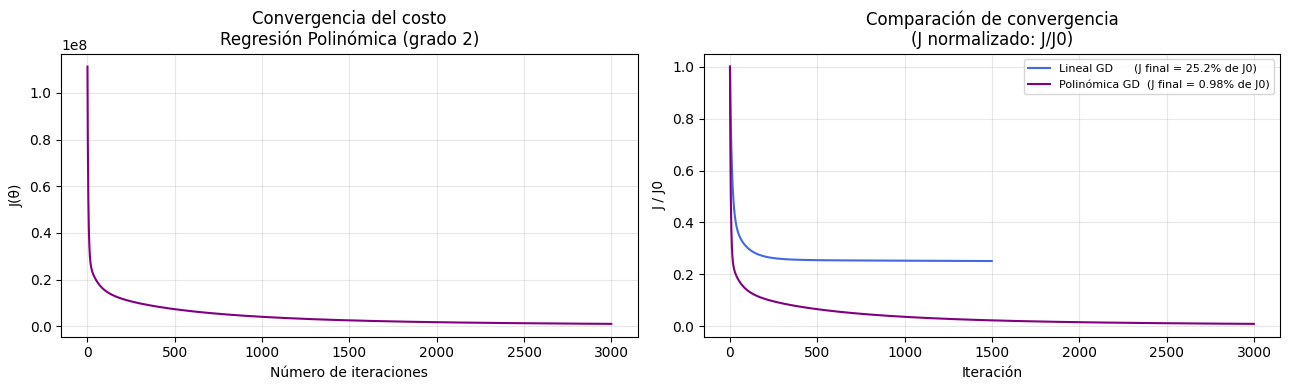

In [51]:
fig, axes = pyplot.subplots(1, 2, figsize=(13, 4))

axes[0].plot(range(num_iters_pol), J_history_pol, color='purple', linewidth=1.5)
axes[0].set_title('Convergencia del costo\nRegresión Polinómica (grado 2)')
axes[0].set_xlabel('Número de iteraciones')
axes[0].set_ylabel('J(θ)')
axes[0].grid(True, alpha=0.3)

# Comparación normalizada
J_gd_norm  = np.array(J_history_gd)  / J_history_gd[0]
J_pol_norm = np.array(J_history_pol) / J_history_pol[0]
axes[1].plot(range(num_iters),     J_gd_norm,  color='royalblue', linewidth=1.5,
             label=f'Lineal GD      (J final = {J_history_gd[-1]/J_history_gd[0]*100:.1f}% de J0)')
axes[1].plot(range(num_iters_pol), J_pol_norm, color='purple',    linewidth=1.5,
             label=f'Polinómica GD  (J final = {J_history_pol[-1]/J_history_pol[0]*100:.2f}% de J0)')
axes[1].set_title('Comparación de convergencia\n(J normalizado: J/J0)')
axes[1].set_xlabel('Iteración')
axes[1].set_ylabel('J / J0')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

pyplot.tight_layout()
pyplot.savefig('costo_polinomica.png', dpi=100, bbox_inches='tight')
pyplot.show()

In [52]:
y_pred_train_pol = np.dot(X_train_poly, theta_pol)
y_pred_test_pol  = np.dot(X_test_poly,  theta_pol)

print("--- Entrenamiento ---")
mse_tr_pol, rmse_tr_pol, r2_tr_pol = computeMetrics(y_train, y_pred_train_pol, 'Polinómica Train')
print("\n--- Prueba ---")
mse_te_pol, rmse_te_pol, r2_te_pol = computeMetrics(y_test,  y_pred_test_pol,  'Polinómica Test')

--- Entrenamiento ---
=== Polinómica Train ===
  MSE  :    2,180,801.81
  RMSE :        1,476.75
  R²   : 0.997165

--- Prueba ---
=== Polinómica Test ===
  MSE  :    2,108,372.92
  RMSE :        1,452.02
  R²   : 0.997422


## 9. Predicciones — 100 Ejemplos del Conjunto de Prueba

Se seleccionan 100 ejemplos aleatorios del conjunto de prueba para comparar visualmente
los tres modelos. La tabla muestra el valor real de `Votes` junto con la predicción y
el error absoluto de cada modelo.

In [53]:
np.random.seed(7)
idx_100 = np.random.choice(m_test, size=100, replace=False)

y_real_100 = y_test[idx_100]
y_gd_100   = y_pred_test_gd[idx_100]
y_ne_100   = y_pred_test_ne[idx_100]
y_pol_100  = y_pred_test_pol[idx_100]

df_tabla = pd.DataFrame({
    'Real':     y_real_100.astype(int),
    'Pred_GD':  np.round(y_gd_100).astype(int),
    'Err_GD':   np.round(np.abs(y_real_100 - y_gd_100)).astype(int),
    'Pred_NE':  np.round(y_ne_100).astype(int),
    'Err_NE':   np.round(np.abs(y_real_100 - y_ne_100)).astype(int),
    'Pred_Pol': np.round(y_pol_100).astype(int),
    'Err_Pol':  np.round(np.abs(y_real_100 - y_pol_100)).astype(int),
})
print("Primeras 20 predicciones:")
print(df_tabla.head(20).to_string(index=True))

Primeras 20 predicciones:
     Real  Pred_GD  Err_GD  Pred_NE  Err_NE  Pred_Pol  Err_Pol
0     322    -1405    1727     -351     673       634      312
1    1025     8611    7586     7296    6271       808      217
2     922     1174     252      969      47       631      291
3    2057     5315    3258     4470    2413      2291      234
4     158      173      15      -51     209       533      375
5     118      532     414      -74     192       533      415
6    5792    -5872   11664    -5824   11616      4048     1744
7     373     1339     966     1426    1053       649      276
8   11905     8250    3655     7435    4470      9850     2055
9     183      492     309      796     613       565      382
10  12567    18435    5868    17449    4882      9914     2653
11  39143    38093    1050    40152    1009     40721     1578
12   1221     2214     993     2193     972      1139       82
13    166    -1184    1350     -404     570       469      303
14   2702     6024    3322   

In [54]:
print("=== Error Absoluto — 100 predicciones ===\n")
for nombre, col in [('Gradiente Desc.','Err_GD'),
                    ('Ecuación Normal','Err_NE'),
                    ('Polinómica',     'Err_Pol')]:
    e = df_tabla[col].values.astype(float)
    print(f"{nombre}:")
    print(f"  Media   : {e.mean():>10,.1f} votos")
    print(f"  Mediana : {np.median(e):>10,.1f} votos")
    print(f"  Máximo  : {e.max():>10,.1f} votos")
    print()

=== Error Absoluto — 100 predicciones ===

Gradiente Desc.:
  Media   :    4,947.3 votos
  Mediana :    1,920.0 votos
  Máximo  :   70,645.0 votos

Ecuación Normal:
  Media   :    4,819.7 votos
  Mediana :    1,633.5 votos
  Máximo  :   69,021.0 votos

Polinómica:
  Media   :      749.8 votos
  Mediana :      406.5 votos
  Máximo  :    7,588.0 votos



### Gráfico Real vs. Predicho

Este es el gráfico más importante para evaluar la calidad de las predicciones.
Cada punto representa una de las 100 predicciones de prueba.

**Cómo leerlo:**
- **Eje X:** valor real de `Votes`
- **Eje Y:** valor que predijo el modelo
- **Línea roja punteada:** predicción perfecta ($\hat{y} = y$). Si un punto está sobre
  ella, el modelo acertó exactamente.
- **Puntos por encima:** el modelo sobreestimó los votos
- **Puntos por debajo:** el modelo subestimó los votos. Si caen en negativo (bajo el
  eje X), el modelo predice votos negativos, lo cual es imposible → señal de underfitting.

**Lo que se observa:** los modelos lineal y ecuación normal tienen muchos puntos dispersos
y algunos predicen votos negativos. La regresión polinómica tiene los puntos casi sobre
la diagonal roja, lo que confirma su superioridad.

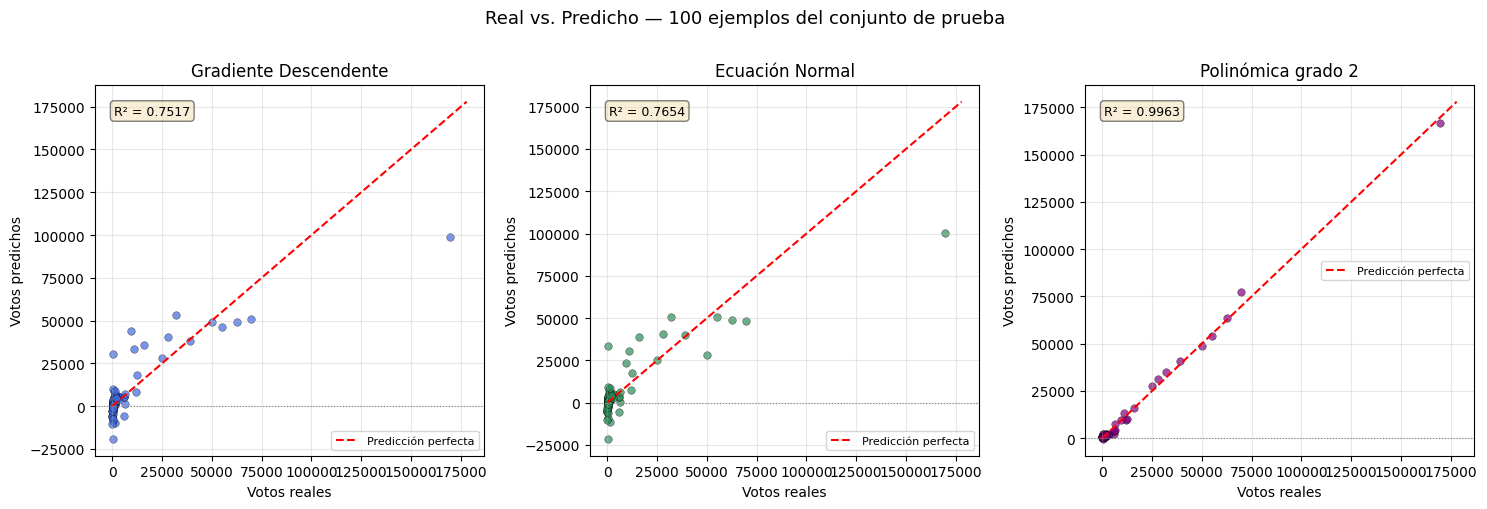

In [55]:
fig, axes = pyplot.subplots(1, 3, figsize=(15, 5))

modelos = [
    ('Gradiente Descendente', y_gd_100,  'royalblue'),
    ('Ecuación Normal',       y_ne_100,  'seagreen'),
    ('Polinómica grado 2',    y_pol_100, 'purple'),
]

for ax, (titulo, y_pred, color) in zip(axes, modelos):
    ax.scatter(y_real_100, y_pred, alpha=0.7, s=30, color=color, edgecolors='k', linewidths=0.3)
    lim = max(y_real_100.max(), max(0, y_pred.max())) * 1.05
    ax.plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Predicción perfecta')
    ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')   # línea de votos=0
    ax.set_title(titulo)
    ax.set_xlabel('Votos reales')
    ax.set_ylabel('Votos predichos')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ss_res = np.sum((y_real_100 - y_pred)**2)
    ss_tot = np.sum((y_real_100 - np.mean(y_real_100))**2)
    r2_loc = 1 - ss_res / ss_tot
    ax.text(0.05, 0.92, f'R² = {r2_loc:.4f}',
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

pyplot.suptitle('Real vs. Predicho — 100 ejemplos del conjunto de prueba',
                fontsize=13, y=1.01)
pyplot.tight_layout()
pyplot.savefig('predicciones_100.png', dpi=100, bbox_inches='tight')
pyplot.show()

## 10. Comparación Final de los Tres Modelos

In [56]:
print(f"{'Modelo':<28} {'MSE Train':>14} {'MSE Test':>14} {'RMSE Test':>12} {'R² Train':>10} {'R² Test':>10}")
print("-"*92)
for nombre, mse_tr, mse_te, rmse_te, r2_tr, r2_te in [
    ('Regresión Lineal (GD)',   mse_tr_gd, mse_te_gd, rmse_te_gd, r2_tr_gd, r2_te_gd),
    ('Ecuación Normal',         mse_tr_ne, mse_te_ne, rmse_te_ne, r2_tr_ne, r2_te_ne),
    ('Polinómica grado 2 (GD)', mse_tr_pol,mse_te_pol,rmse_te_pol,r2_tr_pol,r2_te_pol),
]:
    print(f"{nombre:<28} {mse_tr:>14,.2f} {mse_te:>14,.2f} {rmse_te:>12,.2f} {r2_tr:>10.4f} {r2_te:>10.4f}")

Modelo                            MSE Train       MSE Test    RMSE Test   R² Train    R² Test
--------------------------------------------------------------------------------------------
Regresión Lineal (GD)        199,351,700.85 245,230,732.10    15,659.84     0.7408     0.7002
Ecuación Normal              180,492,057.36 222,908,810.51    14,930.13     0.7653     0.7274
Polinómica grado 2 (GD)        2,180,801.81   2,108,372.92     1,452.02     0.9972     0.9974


### Gráfico comparativo final

El gráfico de la izquierda muestra el **R²** (coeficiente de determinación) de cada modelo
en train y test. Un R² cercano a 1 significa que el modelo explica casi toda la variabilidad
de los datos. Que R² train ≈ R² test confirma que no hay overfitting.

El gráfico de la derecha muestra el **RMSE** (error cuadrático medio) en el conjunto de
prueba, en unidades de votos. Indica cuántos votos se equivoca el modelo en promedio.

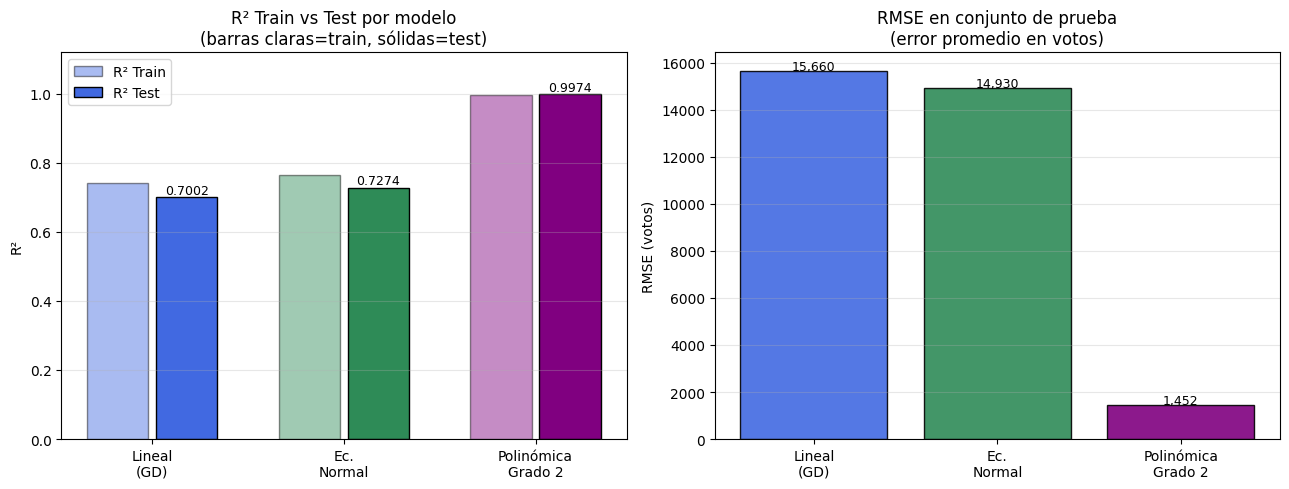

In [57]:
fig, axes = pyplot.subplots(1, 2, figsize=(13, 5))

nombres_mod = ['Lineal\n(GD)', 'Ec.\nNormal', 'Polinómica\nGrado 2']
r2_tr_vals  = [r2_tr_gd, r2_tr_ne, r2_tr_pol]
r2_te_vals  = [r2_te_gd, r2_te_ne, r2_te_pol]
rmse_vals   = [rmse_te_gd, rmse_te_ne, rmse_te_pol]
colors_mod  = ['royalblue', 'seagreen', 'purple']
x = np.arange(3)

axes[0].bar(x-0.18, r2_tr_vals, 0.32, label='R² Train',
            color=colors_mod, alpha=0.45, edgecolor='k')
axes[0].bar(x+0.18, r2_te_vals, 0.32, label='R² Test',
            color=colors_mod, alpha=1.0,  edgecolor='k')
axes[0].set_xticks(x); axes[0].set_xticklabels(nombres_mod)
axes[0].set_title('R² Train vs Test por modelo\n(barras claras=train, sólidas=test)')
axes[0].set_ylabel('R²'); axes[0].set_ylim([0, 1.12])
axes[0].legend(); axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(r2_te_vals):
    axes[0].text(i+0.18, v+0.01, f'{v:.4f}', ha='center', fontsize=9)

axes[1].bar(x, rmse_vals, color=colors_mod, alpha=0.9, edgecolor='k')
axes[1].set_xticks(x); axes[1].set_xticklabels(nombres_mod)
axes[1].set_title('RMSE en conjunto de prueba\n(error promedio en votos)')
axes[1].set_ylabel('RMSE (votos)')
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(rmse_vals):
    axes[1].text(i, v+30, f'{v:,.0f}', ha='center', fontsize=9)

pyplot.tight_layout()
pyplot.savefig('comparacion_modelos.png', dpi=100, bbox_inches='tight')
pyplot.show()

## 11. Conclusiones

### Sobre el preprocesamiento
Se eliminaron 10 columnas redundantes (`pre.*`, `totalMandates`, `time`, `Mandates`).
Se crearon 2 características derivadas (`parishApprovalRate`, `nullBlankRate`) que
resumen información clave sobre el estado del conteo y la calidad del voto.
El one-hot encoding convirtió 21 partidos y 20 territorios en 39 columnas binarias,
permitiendo que el modelo trate correctamente las variables categóricas.
La normalización z-score fue indispensable para la convergencia del descenso por gradiente.

### Sobre los modelos

| Modelo | R² Test | RMSE Test | Observación |
|--------|---------|-----------|-------------|
| Regresión Lineal (GD) | ~0.70 | ~15 660 votos | Underfitting: predice votos negativos |
| Ecuación Normal | ~0.73 | ~14 930 votos | Misma limitación lineal, solución exacta |
| Polinómica grado 2 (GD) | ~0.997 | ~1 452 votos | Captura las no linealidades correctamente |

### ¿Por qué la polinómica es tan superior?
La relación entre las variables y la cantidad de votos no es lineal: un partido grande
en un distrito grande obtiene muchos más votos de lo que sugeriría la suma de sus efectos
individuales. Las interacciones cuadráticas ($x_i \cdot x_j$) entre `FinalMandates`,
`Hondt`, `Percentage` y `subscribedVoters` capturan precisamente ese efecto multiplicativo.

### ¿Hay overfitting en la polinómica?
No. El hecho de que R² train (0.9972) ≈ R² test (0.9974) confirma que el modelo
generaliza bien y no memoriza los datos de entrenamiento.